In [1]:
from pathlib import Path
from IPython.display import display, Markdown

from resources.imports import *
import torch

from resources.MLmetrics import (
    postprocess_list_runs,
    postprocess_artifact_table,
    postprocess_load_field_run,
    postprocess_field_run_overview,
    display_field_run_overview,
    postprocess_build_active_field_diagnostics,
    field_summary_table,
    print_field_diagnostics,
    plot_field_frame_component_trends,
    plot_field_frame_component_heatmaps,
    plot_field_diversity,
    display_field_sample_error_summary,
    display_field_node_error_summary,
    field_sample_viewer,
    plot_field_sample_frame_evolution,
    plot_field_frame_component_collapse,
    plot_field_component_parity,
    plot_field_keyframe_strip,
    plot_loss_history,
)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [2]:
%load_ext autoreload
%autoreload 2

# ML Field Post-Processing

## 1. Find Recent Runs

In [3]:
FIND_RUN = False
RUN_ROOT = Path(r"Z:/p2")

if FIND_RUN:
    recent_runs = postprocess_list_runs(RUN_ROOT, max_runs=25, include_hpo=True)
    display(recent_runs)
    if recent_runs.empty:
        raise ValueError("No saved runs were found. Set RUN_PATH manually.")

## 2. User Configuration

Set the run identity here. `output_kind` separates field and curve archives; `run_type` controls whether the path points to a standard run, a model-specific HPO run, or one model inside a cross-model HPO run.


In [4]:
mechMode = "FT"
output_kind = "Field"
model = "Transformer"
run_name = "fFT-fHPO"
VIEW_MODE = None
run_type = "full_hpo"  # "standard", "model_hpo", or "full_hpo"
RUN_PATH_OVERRIDE = None

if RUN_PATH_OVERRIDE is not None:
    RUN_PATH = Path(RUN_PATH_OVERRIDE)
elif run_type == "standard":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / model / run_name
elif run_type == "model_hpo":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / model / "HPO" / run_name
elif run_type == "full_hpo":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / "HPO" / run_name / model
else:
    raise ValueError("run_type must be 'standard', 'model_hpo', or 'full_hpo'.")

DATA_PATH_OVERRIDE = None

if VIEW_MODE is None:
    VIEW_MODE = mechMode if str(mechMode).upper() in ["UT", "FT"] else "UT"
VIEW_MODE = str(VIEW_MODE).upper()
if VIEW_MODE not in ["UT", "FT"]:
    raise ValueError("VIEW_MODE must be UT or FT. For MULTI runs, choose which output branch to view.")

LOAD_DATA = True
LOAD_MODEL = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ACTIVE_SPLIT = None


## 3. Load Run Artifacts

In [5]:
artifacts, loaded, DAT, MOD = postprocess_load_field_run(
    RUN_PATH,
    run_root=RUN_ROOT,
    load_data=LOAD_DATA,
    load_model=LOAD_MODEL,
    data_path_override=DATA_PATH_OVERRIDE,
    device=DEVICE,
)


display(postprocess_artifact_table(artifacts))
for warning in artifacts.get("warnings", []):
    print("WARNING:", warning)


Loaded DATA from: Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_model_data.json
DATA output_kind: field
Loaded MODEL from: Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_model.json


,artifact,path_or_value
0,input_path,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer
1,run_dir,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer
2,model_json,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
3,model_mdl,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
4,data_json,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
5,results_dir,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
6,metrics_json,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
7,predictions_npz,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
8,loss_history_csv,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...
9,diagnostics_summary_json,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...


## 4. Run Setup And Available Outputs

In [6]:
overview = postprocess_field_run_overview(
    artifacts,
    loaded,
    data=DAT,
    run_name=run_name,
    run_type=run_type,
    mech_mode=mechMode,
    view_mode=VIEW_MODE,
    model_name=model,
    device=DEVICE,
    active_split=ACTIVE_SPLIT,
)


available_evals = overview["available_evals"]
available_field_evals = overview["available_field_evals"]
ACTIVE_SPLIT = overview["active_split"]

display_field_run_overview(overview)
print("mechMode:", mechMode)
print("VIEW_MODE:", VIEW_MODE)
print("ACTIVE_SPLIT:", ACTIVE_SPLIT)


,item,value
0,run,fFT-fHPO
1,run_type,full_hpo
2,mechMode,FT
3,VIEW_MODE,FT
4,model,Transformer
5,output_kind,field
6,device,cpu
7,evaluation_split,val
8,is_hpo,True
9,model_json,Z:\p2\FT\Field\HPO\fFT-fHPO\Transformer\best_m...


### Saved Metrics For Active View

,metric,value
0,FT_best_epoch,40
1,FT_best_loss,0.000235
2,FT_best_mse,0.000235
3,FT_best_rmse,"[False, 0.015321432783778625]"


### Available Field Predictions / Diagnostic Tables

,mode,split,outputs,truth,sample_metrics,frame_metrics,component_metrics,node_metrics
0,FT,val,True,True,True,True,True,True


...

#### best_params

,parameter,value
0,tr_act,mish
1,tr_norm,layer
2,tr_dropout,0.263865
3,tr_head_dropout,0.061815
4,tr_d_model,256
5,tr_n_heads,4
6,tr_use_cls_token,False
7,tr_head_depth,0
8,tr_head_width,128
9,tr_n_layers,5


#### best_trial_user_attrs

,parameter,value
0,best_model_checkpoint,/gpfs/scratch/exy053/12465873/mlruns/FT/Field/...
1,loss_params,"{'family': 'field_mse', 'reduction': 'mean', '..."
2,model_params,"{'in_size': 8, 'seq_len': 788, 'out_size': 40,..."
3,task_scores,[0.015321432783778625]
4,train_params,"{'lr': 7.442834613199463e-05, 'weight_decay': ..."
5,typ,tr


mechMode: FT
VIEW_MODE: FT
ACTIVE_SPLIT: val


## 5. Build Active Field Diagnostics

In [7]:
diagnostics, active_key, active_diag = postprocess_build_active_field_diagnostics(
    DAT,
    loaded,
    available_evals,
    view_mode=VIEW_MODE,
    active_split=ACTIVE_SPLIT,
    model=MOD,
)


if active_diag is None:
    print("No active diagnostics are available. Check predictions.npz, diagnostic CSVs, VIEW_MODE, or ACTIVE_SPLIT.")
else:
    print_field_diagnostics(active_diag, label=f"{active_key[0]} {active_key[1]}")


FT val prediction diagnostics | RMSE: 0.1102 | MAE: 0.04722 | mean-field RMSE: 0.1497 | skill vs mean field: 0.264 | collapse ratio: 0.843 | valid: 1


## 6. Active Diagnostic Summary

In [8]:
SUMMARY_METRICS = [
    "rmse",
    "mae",
    "mse",
    "bias",
    "collapse_ratio",
    "mean_field_baseline_rmse",
    "skill_vs_mean_field_rmse",
    "valid_fraction",
    "n_samples",
    "n_frames",
    "n_nodes",
    "n_components",
]


if active_diag is None:
    print("No active diagnostics are available.")
else:
    display(field_summary_table(active_diag, metrics=SUMMARY_METRICS))


,metric,value
0,rmse,0.110204
1,mae,0.047222
2,mse,0.012145
3,bias,-0.001516
4,collapse_ratio,0.843431
5,mean_field_baseline_rmse,0.149750
6,skill_vs_mean_field_rmse,0.264075
7,valid_fraction,1.000000
8,n_samples,804.000000
9,n_frames,20.000000


## 7. Frame And Component Performance

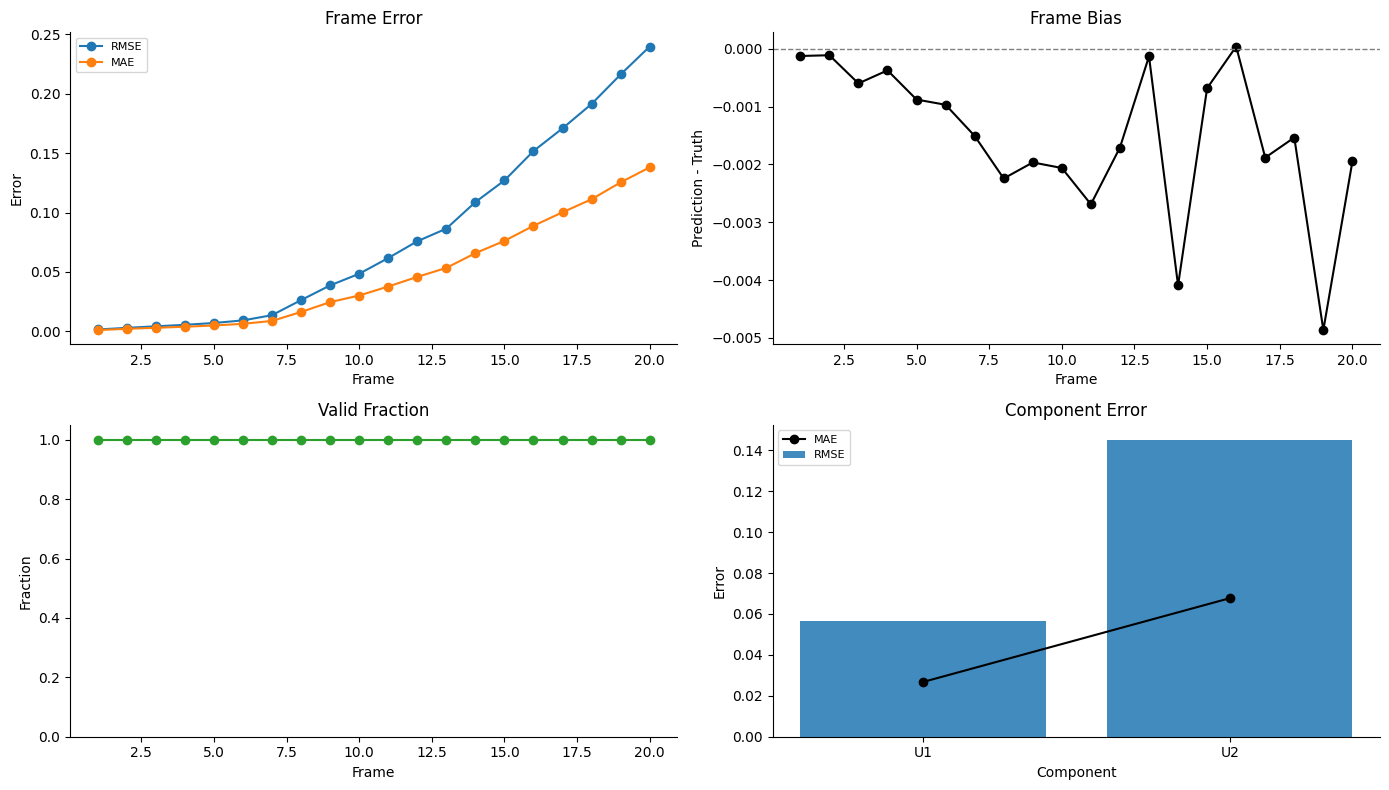

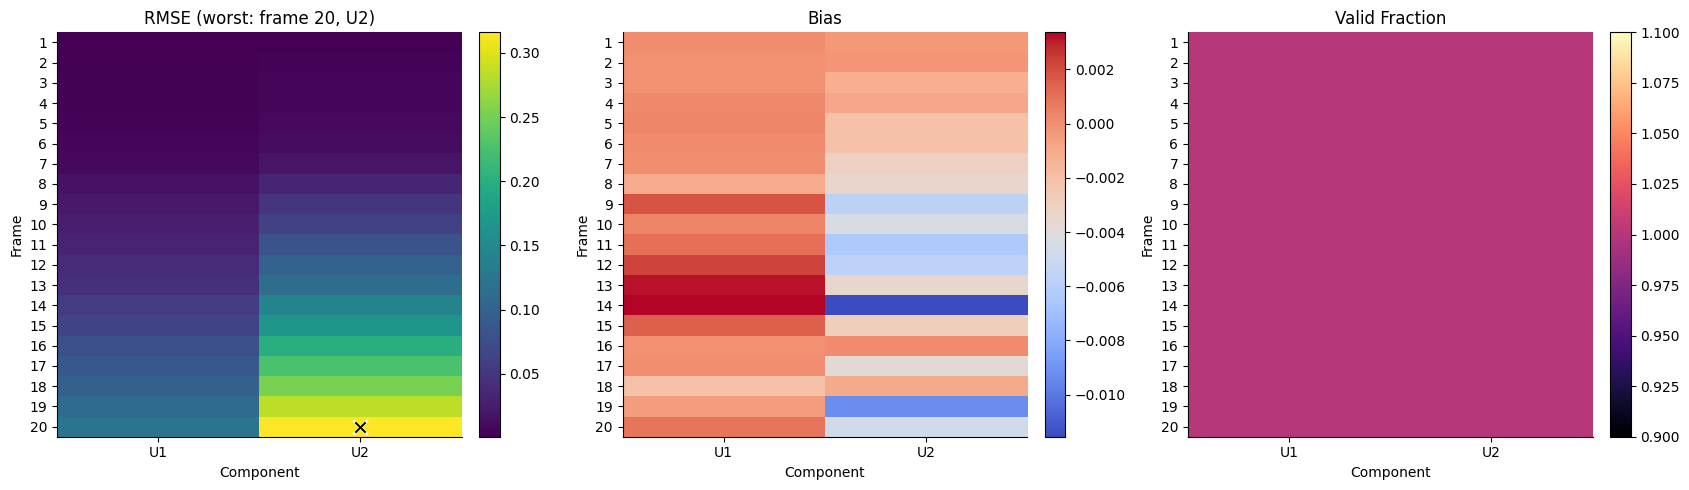

### Component Metrics

,component,mae,mse,rmse,bias,valid_fraction
0,U1,0.026753,0.003217,0.056716,0.000567,1.0
1,U2,0.067691,0.021073,0.145166,-0.003599,1.0


In [9]:
FRAME_TRENDS_FIGSIZE = (14, 8)
HEATMAP_FIGSIZE = (17, 5)
HEATMAP_CMAPS = {"RMSE": "viridis", "Bias": "coolwarm", "Valid Fraction": "magma"}
SHOW_COMPONENT_TABLE = True


if active_diag is None:
    print("No active diagnostics are available.")
else:
    plot_field_frame_component_trends(active_diag, figsize=FRAME_TRENDS_FIGSIZE)
    plot_field_frame_component_heatmaps(active_diag, figsize=HEATMAP_FIGSIZE, cmaps=HEATMAP_CMAPS)

    component_metrics = active_diag.get("component_metrics")
    if SHOW_COMPONENT_TABLE and hasattr(component_metrics, "copy"):
        display(Markdown("### Component Metrics"))
        display(component_metrics)


## 8. Prediction Collapse And Field Diversity

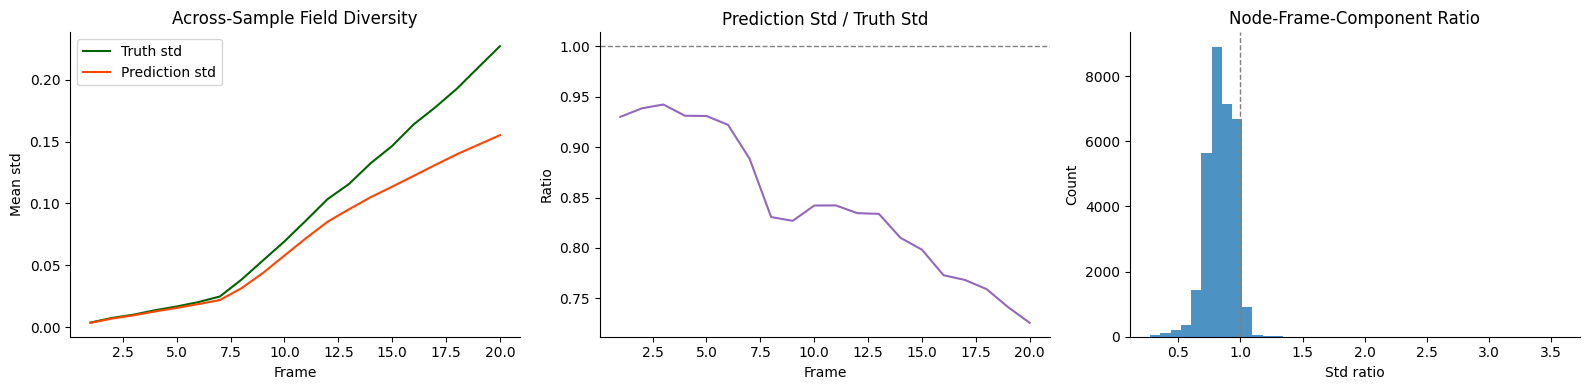

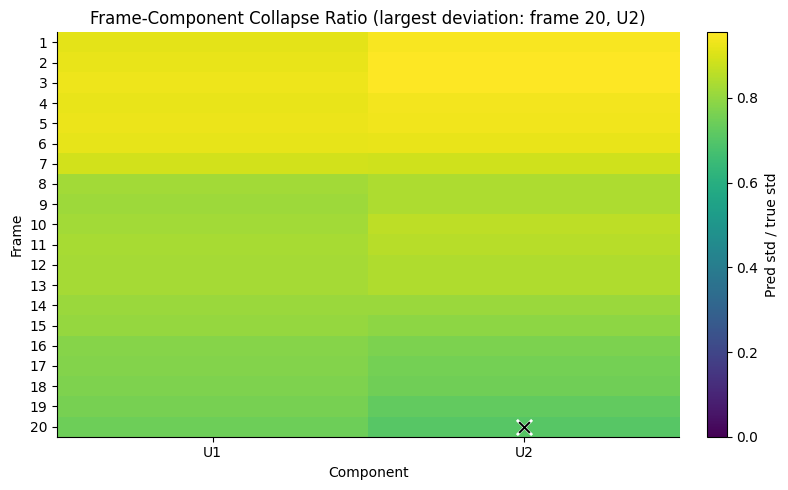

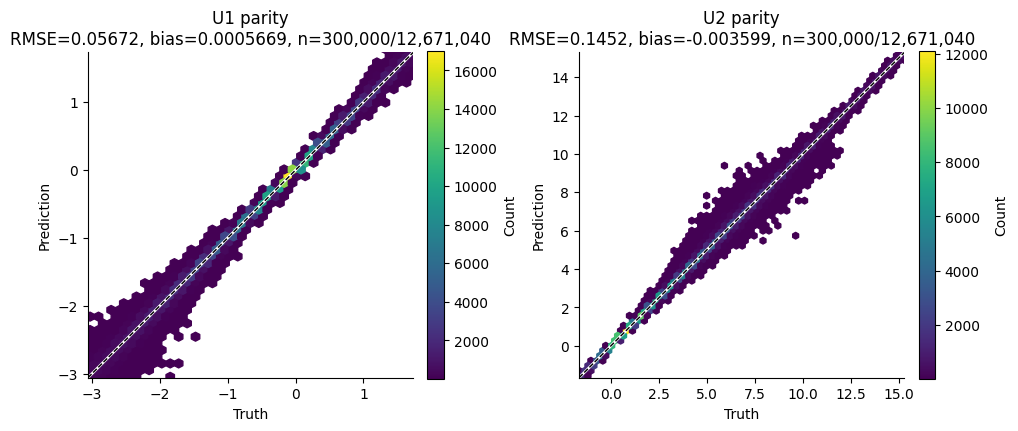

In [10]:
DIVERSITY_FIGSIZE = (16, 4)
DIVERSITY_RATIO_REFERENCE = 1.0
DIVERSITY_BINS = 40
COLLAPSE_HEATMAP_FIGSIZE = (8, 5)
FIELD_PARITY_COMPONENTS = None
FIELD_PARITY_MAX_POINTS_PER_COMPONENT = 300000
FIELD_PARITY_GRIDSIZE = 70
FIELD_PARITY_FIGSIZE = None


if active_diag is None:
    print("No active diagnostics are available.")
else:
    try:
        plot_field_diversity(
            active_diag,
            figsize=DIVERSITY_FIGSIZE,
            ratio_reference=DIVERSITY_RATIO_REFERENCE,
            bins=DIVERSITY_BINS,
        )
        plot_field_frame_component_collapse(
            active_diag,
            figsize=COLLAPSE_HEATMAP_FIGSIZE,
        )
        plot_field_component_parity(
            active_diag,
            components=FIELD_PARITY_COMPONENTS,
            max_points_per_component=FIELD_PARITY_MAX_POINTS_PER_COMPONENT,
            gridsize=FIELD_PARITY_GRIDSIZE,
            figsize=FIELD_PARITY_FIGSIZE,
        )
    except ValueError as exc:
        print(exc)


## 9. Sample-Level Error

### Best And Worst Samples By RMSE

,sample,sample_mae,sample_mse,sample_rmse,sample_bias,valid_fraction
520,520,0.019675,0.001408,0.037524,0.000794,1.0
199,199,0.022705,0.001616,0.040195,0.006722,1.0
66,66,0.021990,0.001772,0.042098,0.001560,1.0
488,488,0.024199,0.001802,0.042447,0.003413,1.0
603,603,0.025056,0.001841,0.042907,-0.007075,1.0
257,257,0.138228,0.099997,0.316223,0.011596,1.0
322,322,0.140566,0.114607,0.338537,0.071976,1.0
629,629,0.157558,0.120570,0.347232,0.006399,1.0
627,627,0.171535,0.143227,0.378453,0.106933,1.0
670,670,0.161777,0.152730,0.390807,0.093926,1.0


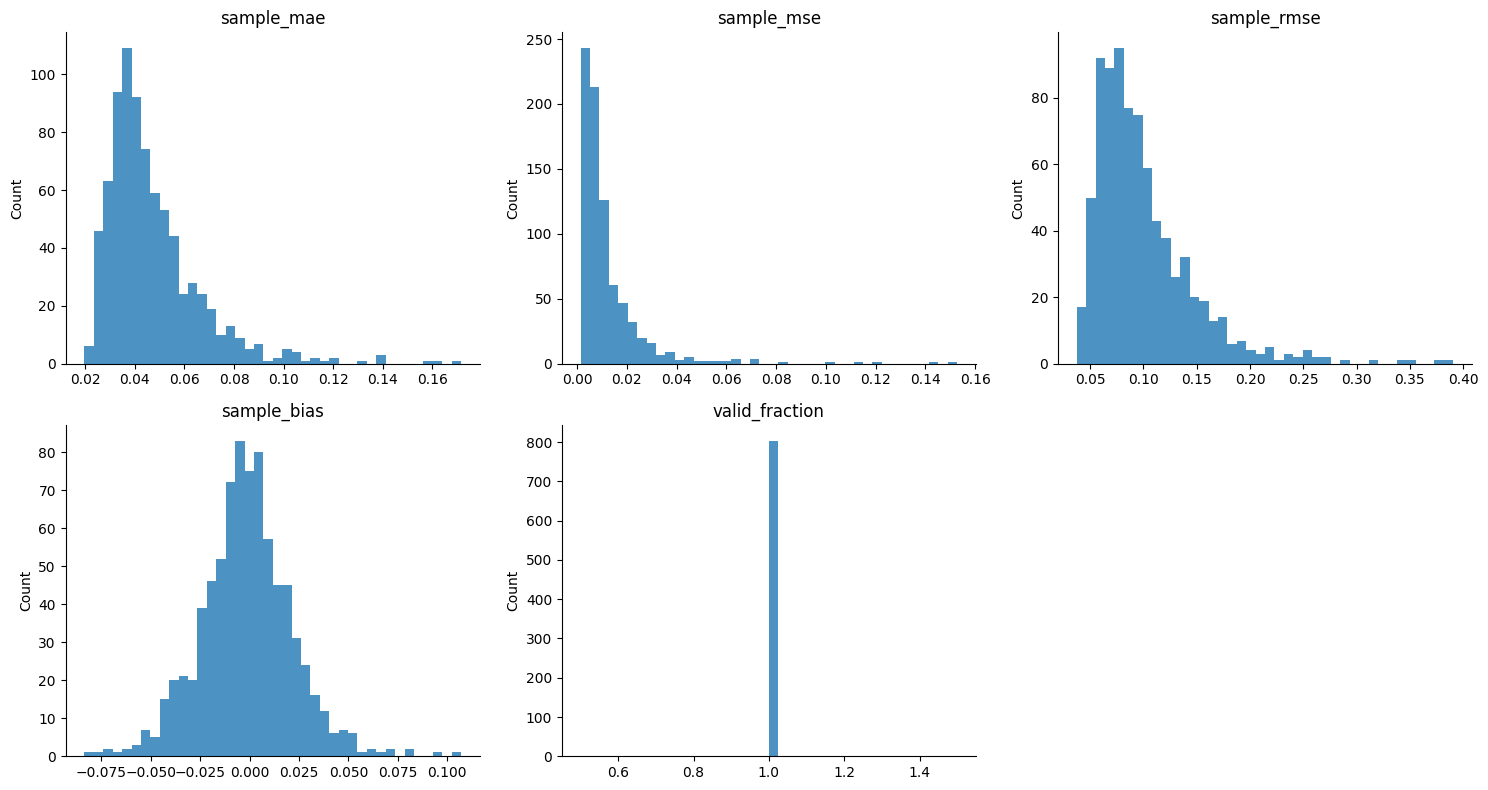

### Sample Metric Summary

,count,mean,std,min,25%,50%,75%,max
sample_mae,804.0,0.047222,0.019550,0.019675,0.034502,0.041995,0.054726,0.171535
sample_mse,804.0,0.012145,0.014431,0.001408,0.004612,0.007663,0.013832,0.152730
sample_rmse,804.0,0.099872,0.046619,0.037524,0.067915,0.087539,0.117612,0.390807
sample_bias,804.0,-0.001516,0.023316,-0.083521,-0.015230,-0.001650,0.011754,0.106933
valid_fraction,804.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
SAMPLE_DISTRIBUTION_BINS = 40
SAMPLE_DISTRIBUTION_NCOLS = 3
SAMPLE_TABLE_TOP_N = 5
SAMPLE_DESCRIBE_COLUMNS = ["sample_mae", "sample_mse", "sample_rmse", "sample_bias", "valid_fraction"]


display_field_sample_error_summary(
    active_diag,
    bins=SAMPLE_DISTRIBUTION_BINS,
    ncols=SAMPLE_DISTRIBUTION_NCOLS,
    top_n=SAMPLE_TABLE_TOP_N,
    columns=SAMPLE_DESCRIBE_COLUMNS,
)


## 10. Node-Level Spatial Error

### Worst Nodes By rmse

,node,node_label,mae,mse,rmse,bias,valid_fraction,x,y
526,526,527,0.150784,0.110173,0.331924,-0.000218,1.0,125.0,95.0
371,371,372,0.143156,0.093741,0.306171,-0.006558,1.0,135.0,95.0
360,360,361,0.122515,0.076081,0.275828,0.005349,1.0,130.0,100.0
361,361,362,0.120044,0.071144,0.266729,-0.014967,1.0,130.0,90.0
362,362,363,0.116328,0.062696,0.250391,-0.006693,1.0,140.0,90.0
333,333,334,0.112954,0.059231,0.243375,-0.004489,1.0,140.0,100.0
334,334,335,0.115125,0.055401,0.235375,-0.001759,1.0,145.0,95.0
412,412,413,0.107321,0.049442,0.222355,0.003933,1.0,195.0,95.0
411,411,412,0.110501,0.049293,0.222020,-0.002081,1.0,200.0,90.0
410,410,411,0.108331,0.047861,0.218771,-0.002904,1.0,200.0,100.0


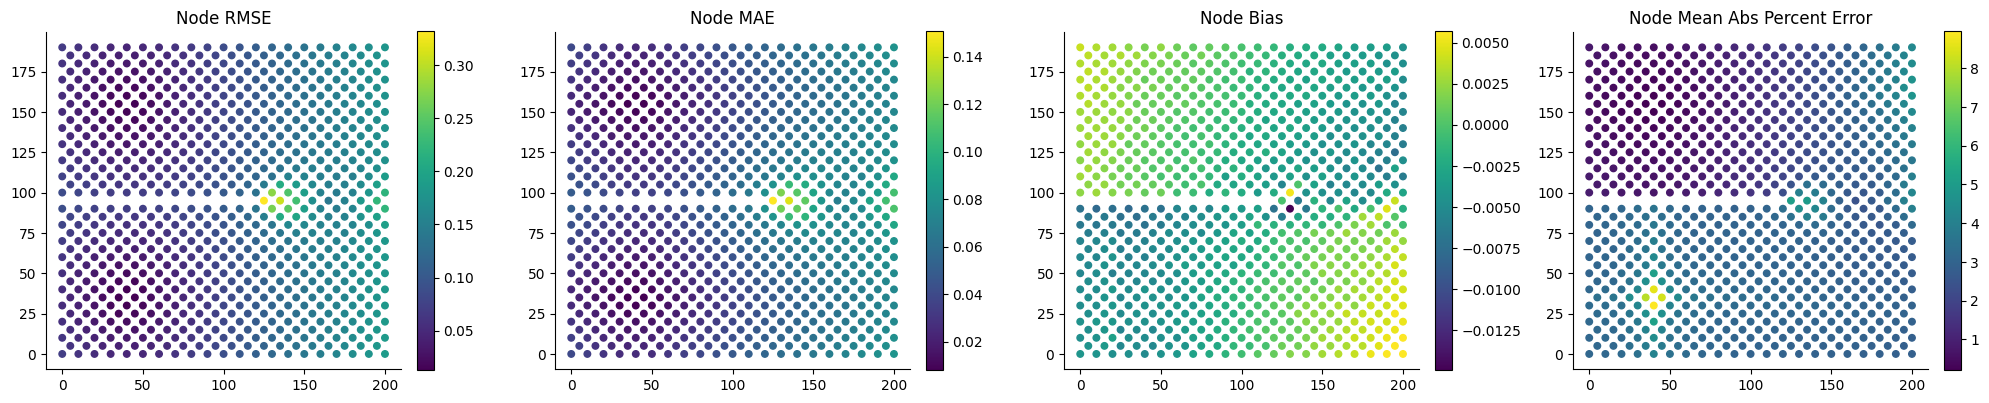

In [12]:
NODE_METRIC = "rmse"
NODE_TABLE_TOP_N = 20
NODE_PLOT_COLUMNS = ["rmse", "mae", "bias", "mean_abs_percent_error"]
NODE_POINT_SIZE = 22


display_field_node_error_summary(
    active_diag,
    metric=NODE_METRIC,
    top_n=NODE_TABLE_TOP_N,
    plot_columns=NODE_PLOT_COLUMNS,
    point_size=NODE_POINT_SIZE,
)


## 11. Interactive Field Viewer

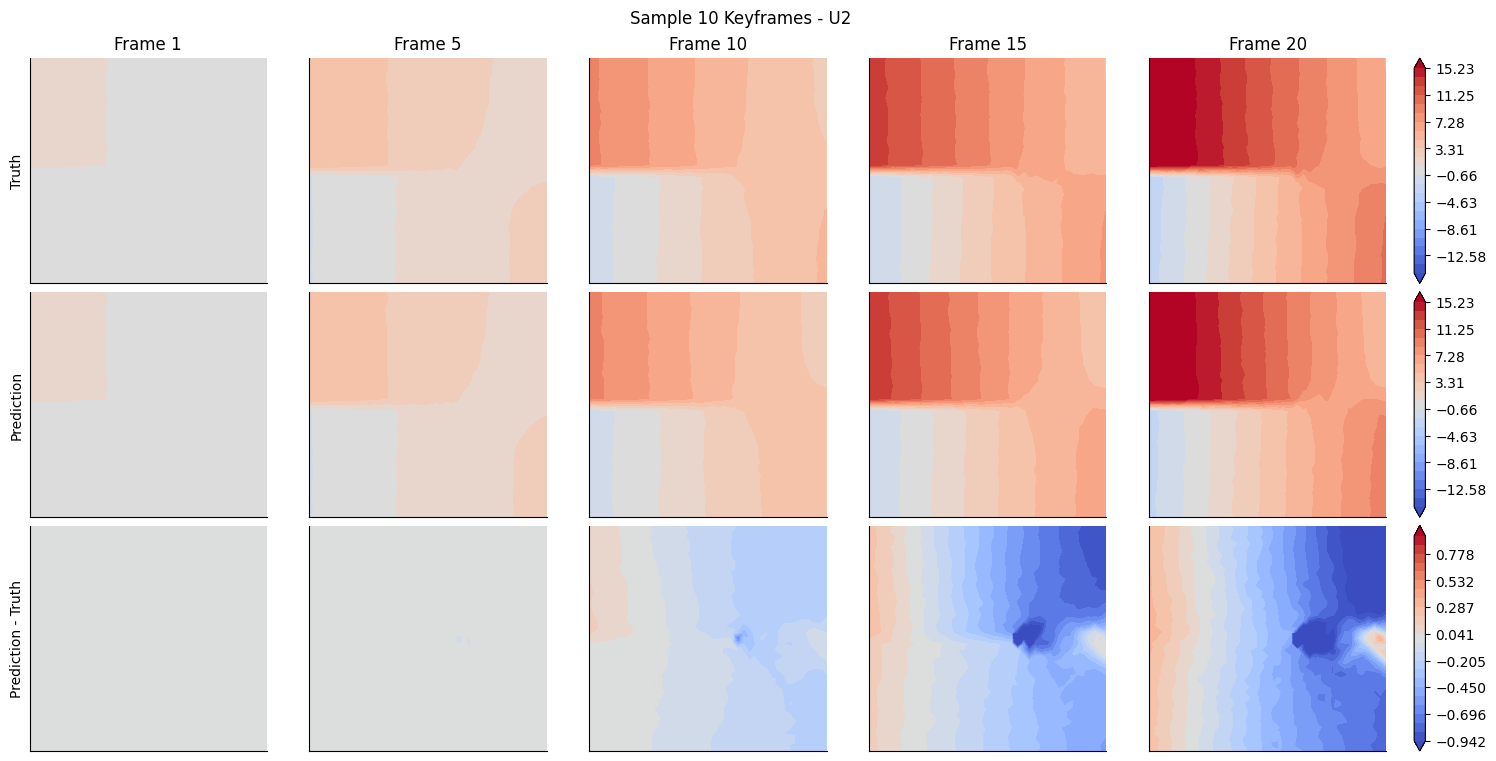

Output()

(VBox(children=(HBox(children=(ToggleButtons(description='Samples', options=('selected', 'best', 'worst', 'random'), value='selected'), Text(value='10', description='Selected', layout=Layout(width='260px'), placeholder='0 or 0, 4, 12'), BoundedIntText(value=5, description='Random n', layout=Layout(width='150px'), max=20, min=5), Button(button_style='primary', description='Refresh', layout=Layout(margin='0 0 0 16px', width='80px'), style=ButtonStyle()))), HBox(children=(HBox(children=(Label(value='Frame', layout=Layout(width='44px')), Button(description='-', layout=Layout(margin='0 2px 0 0', width='30px'), style=ButtonStyle()), IntSlider(value=10, continuous_update=False, layout=Layout(width='190px'), max=20, min=1), Button(description='+', layout=Layout(margin='0 0 0 2px', width='30px'), style=ButtonStyle())), layout=Layout(align_items='center', margin='0 14px 0 0')), Dropdown(description='Component', index=1, layout=Layout(width='185px'), options=(('U1', 0), ('U2', 1)), style=Descript

In [13]:
FIELD_SAMPLE_MODE = "selected"
FIELD_SELECTED_SAMPLES = 10
FIELD_VIEW_FRAME = 10
FIELD_VIEW_COMPONENT = "U2"
FIELD_RANKING_METRIC = "rmse"
FIELD_PLOT_STYLE = "continuous"
FIELD_RANDOM_COUNT = 5
FIELD_KEYFRAME_FRAMES = None
FIELD_KEYFRAME_COUNT = 5
FIELD_KEYFRAME_ROWS = ("truth", "prediction", "error")
FIELD_KEYFRAME_PLOT_STYLE = "continuous"


plot_field_keyframe_strip(
    active_diag,
    sample=FIELD_SELECTED_SAMPLES,
    component=FIELD_VIEW_COMPONENT,
    frames=FIELD_KEYFRAME_FRAMES,
    n_keyframes=FIELD_KEYFRAME_COUNT,
    rows=FIELD_KEYFRAME_ROWS,
    plot_style=FIELD_KEYFRAME_PLOT_STYLE,
)

field_sample_viewer(
    active_diag,
    sample_mode=FIELD_SAMPLE_MODE,
    selected_samples=FIELD_SELECTED_SAMPLES,
    frame=FIELD_VIEW_FRAME,
    component=FIELD_VIEW_COMPONENT,
    ranking_metric=FIELD_RANKING_METRIC,
    plot_style=FIELD_PLOT_STYLE,
    random_count=FIELD_RANDOM_COUNT,
)


## 12. Selected Sample Frame Evolution

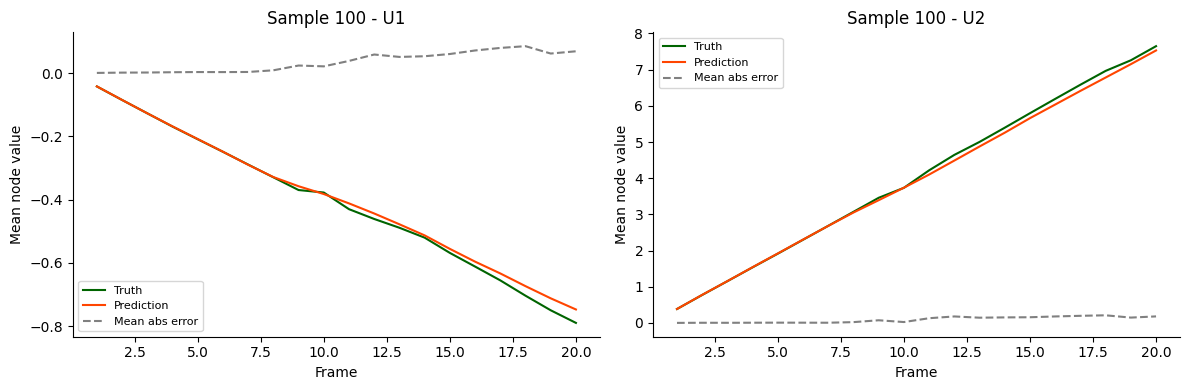

(<Figure size 1200x400 with 2 Axes>,
 array([[<Axes: title={'center': 'Sample 100 - U1'}, xlabel='Frame', ylabel='Mean node value'>,
         <Axes: title={'center': 'Sample 100 - U2'}, xlabel='Frame', ylabel='Mean node value'>]],
       dtype=object))

In [14]:
FRAME_EVOLUTION_SAMPLE = 100


plot_field_sample_frame_evolution(active_diag, sample=FRAME_EVOLUTION_SAMPLE)


## 13. Training Loss History

In [ ]:
LOSS_HISTORY_METRICS = ["train_loss", "val_loss"]
LOSS_HISTORY_FIGSIZE = (9, 4)


loss_history = loaded.get("loss_history")
if loss_history is not None and hasattr(loss_history, "empty") and not loss_history.empty:
    display(loss_history.head())
plot_loss_history(loss_history, metrics=LOSS_HISTORY_METRICS, figsize=LOSS_HISTORY_FIGSIZE)
